# Overtake Probability Model v5 — IP04 Implementation

**Data version:** `data/v5` (79 columns per row)  
**New over v4:** constructor/team features, richer driver form, race-situation context  
**Baseline:** v4 (IP03) — see comparison at bottom

### IP04 highlights implemented in v5
| Feature group | New columns |
|---|---|
| Team/constructor (§1.1) | `attacker_team`, `defender_team`, `same_team`, `attacker_team_pace_rank`, `defender_team_pace_rank`, `team_delta` |
| Driver form (§1.2) | `attacker_positions_gained_avg`, `defender_positions_gained_avg`, `attacker_quali_vs_teammate`, `defender_quali_vs_teammate`, `attacker_race_pace_vs_teammate`, `defender_race_pace_vs_teammate` |
| Race situation (§1.3) | `gap_to_car_ahead`, `gap_to_car_behind`, `drs_train_size`, `race_phase`, `stint_phase` |

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, f1_score,
    classification_report, confusion_matrix,
)

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

import sys
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))
from pipeline.pair_aggregation import aggregate_battle_pairs

try:
    import shap
except ImportError:
    shap = None

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load v5 data — train (2022–2024) and test (2025)

In [2]:
TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEARS  = [2025]
DATA_DIR = Path("../data/v5")

def load_years(years):
    frames = []
    for yr in years:
        p = DATA_DIR / f"battles_{yr}.csv"
        if not p.exists():
            print(f"WARNING: {p} not found — skipping {yr}")
            continue
        frames.append(pd.read_csv(p, encoding="utf-8"))
        print(f"  {yr}: {len(frames[-1]):,} battles")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Training data (2022-2024):")
df_train_raw = load_years(TRAIN_YEARS)
print(f"  Total train rows : {len(df_train_raw):,}")
print(f"  Overtake rate    : {df_train_raw['overtake'].mean():.2%}")
print()
print("Test data (2025 holdout):")
df_test_raw = load_years(TEST_YEARS)
if not df_test_raw.empty:
    print(f"  Total test rows  : {len(df_test_raw):,}")
    print(f"  Overtake rate    : {df_test_raw['overtake'].mean():.2%}")
else:
    print("  No 2025 data available")

Training data (2022-2024):
  2022: 713 battles
  2023: 1,744 battles
  2024: 2,245 battles
  Total train rows : 4,702
  Overtake rate    : 8.06%

Test data (2025 holdout):
  2025: 1,630 battles
  Total test rows  : 1,630
  Overtake rate    : 7.18%


## 2. Data quality — filter pit-stop overtakes

In [3]:
pit_train = df_train_raw["pit_stop_involved"].sum()
pit_test  = df_test_raw["pit_stop_involved"].sum() if not df_test_raw.empty else 0
print(f"Pit-stop battles removed — train: {pit_train:,}, test: {pit_test:,}")

df_train = df_train_raw[~df_train_raw["pit_stop_involved"]].copy()
df_test  = df_test_raw[~df_test_raw["pit_stop_involved"]].copy() if not df_test_raw.empty else pd.DataFrame()
print(f"Remaining — train: {len(df_train):,}, test: {len(df_test):,}")

Pit-stop battles removed — train: 254, test: 66
Remaining — train: 4,448, test: 1,564


## 3. Feature engineering

In [4]:
def identify_battle_sequences(df):
    df = df.sort_values(["race_name", "attacker", "defender", "lap_number"]).copy()
    df["pair_id"] = df["attacker"] + "_vs_" + df["defender"]
    df["lap_gap"] = df.groupby(["race_name", "pair_id"])["lap_number"].diff().fillna(1)
    df["battle_break"] = (df["lap_gap"] > 1).astype(int)
    df["battle_seq"] = df.groupby(["race_name", "pair_id"])["battle_break"].cumsum()
    df["battle_group"] = df["race_name"] + "_" + df["pair_id"] + "_" + df["battle_seq"].astype(str)
    return df

def engineer_features(df):
    df = identify_battle_sequences(df)
    df["position_delta"] = df["attacker_position"] - df["defender_position"]
    df["compound_advantage"] = (
        df["attacker_tyre_compound"].map({"SOFT": 3, "MEDIUM": 2, "HARD": 1}).fillna(0)
        - df["defender_tyre_compound"].map({"SOFT": 3, "MEDIUM": 2, "HARD": 1}).fillna(0)
    )
    df["tyre_cliff_risk"] = (df["attacker_tyre_age"] >= 20).astype(int)
    df["qualification_rank_difference"] = (
        df["defender_qualification_rank"] - df["attacker_qualification_rank"]
    )
    g = df.groupby("battle_group")
    df["battle_duration"] = g["lap_number"].transform("count")
    df["closing_rate"] = g["gap_ahead"].transform(lambda s: s.diff().mean())
    df["closing_rate"] = df["closing_rate"].fillna(0)
    return df

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test) if not df_test.empty else pd.DataFrame()

print(f"After feature engineering — train columns: {len(df_train.columns)}")
print(f"New IP04 columns in data: {[c for c in df_train.columns if c in ['attacker_team','defender_team','same_team','gap_to_car_ahead','gap_to_car_behind','drs_train_size','race_phase','stint_phase','attacker_team_pace_rank','defender_team_pace_rank','team_delta','attacker_positions_gained_avg','defender_positions_gained_avg','attacker_quali_vs_teammate','defender_quali_vs_teammate','attacker_race_pace_vs_teammate','defender_race_pace_vs_teammate']]}")

After feature engineering — train columns: 90
New IP04 columns in data: ['attacker_team', 'defender_team', 'same_team', 'gap_to_car_ahead', 'gap_to_car_behind', 'drs_train_size', 'race_phase', 'stint_phase', 'attacker_team_pace_rank', 'defender_team_pace_rank', 'team_delta', 'attacker_positions_gained_avg', 'defender_positions_gained_avg', 'attacker_quali_vs_teammate', 'defender_quali_vs_teammate', 'attacker_race_pace_vs_teammate', 'defender_race_pace_vs_teammate']


## 4. Prepare train/test matrices

In [5]:
DROP_COLS = [
    "attacker", "defender", "overtake", "track",
    "attacker_qualification_rank", "defender_qualification_rank",
    "pit_stop_involved",
    "event_date",
    "overtake_within_2",
    "overtake_within_3",
    "pair_id", "lap_gap", "battle_break", "battle_seq", "battle_group",
]

FEATURE_COLS = [c for c in df_train.columns if c not in DROP_COLS]
TARGET = "overtake"

X = df_train[FEATURE_COLS].copy()
y = df_train[TARGET].astype(int).values
groups = df_train["race_name"].values

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print(f"Features: {len(FEATURE_COLS)}")
print(f"  Numeric    : {len(num_cols)}")
print(f"  Categorical: {len(cat_cols)}")
print(f"  Positive rate: {y.mean():.2%}")
print(f"\nCategorical: {cat_cols}")
print(f"Numeric (first 20): {num_cols[:20]}")
print(f"Numeric (rest):     {num_cols[20:]}")

if not df_test.empty:
    X_test = df_test[FEATURE_COLS].copy()
    y_test = df_test[TARGET].astype(int).values
else:
    X_test = y_test = None

Features: 75
  Numeric    : 58
  Categorical: 17
  Positive rate: 6.36%

Categorical: ['race_name', 'safety_car', 'yellow_flag', 'attacker_tyre_compound', 'defender_tyre_compound', 'attacker_fresh_tyre', 'defender_fresh_tyre', 'sector_type', 'is_in_drs_zone', 'track_type', 'rainfall', 'compound_mismatch', 'attacker_team', 'defender_team', 'same_team', 'race_phase', 'stint_phase']
Numeric (first 20): ['year', 'round_number', 'lap_number', 'total_laps', 'race_progress', 'attacker_position', 'defender_position', 'attacker_lap_time', 'defender_lap_time', 'gap_ahead', 'pace_delta', 'attacker_speed_i1', 'defender_speed_i1', 'attacker_speed_i2', 'defender_speed_i2', 'attacker_finish_line_speed', 'defender_finish_line_speed', 'attacker_straight_speed', 'defender_straight_speed', 'speed_i1_delta']
Numeric (rest):     ['speed_i2_delta', 'speed_fl_delta', 'speed_st_delta', 'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference', 'attacker_stint', 'defender_stint', 'sector', 'drs_zone_leng

## 5. Preprocessing

In [6]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
print(f"Preprocessor: {len(num_cols)} numeric, {len(cat_cols)} categorical columns")

Preprocessor: 58 numeric, 17 categorical columns


## 6. XGBoost with Optuna Bayesian tuning

In [7]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

X_transformed = preprocessor.fit_transform(X)

scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)
print(f"scale_pos_weight = {scale_pos_weight:.1f}")


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "aucpr",
        "random_state": 42,
        "n_jobs": -1,
    }

    clf = xgb.XGBClassifier(**params)
    probas = cross_val_predict(
        clf, X_transformed, y,
        cv=gkf, groups=groups,
        method="predict_proba", n_jobs=1,
    )[:, 1]

    return average_precision_score(y, probas)


study = optuna.create_study(direction="maximize", study_name="xgb_v5")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

scale_pos_weight = 14.7


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.61804:   0%|          | 0/40 [00:02<?, ?it/s]

Best trial: 0. Best value: 0.61804:   2%|▎         | 1/40 [00:02<01:34,  2.42s/it]

Best trial: 0. Best value: 0.61804:   2%|▎         | 1/40 [00:05<01:34,  2.42s/it]

...

Best trial: 27. Best value: 0.654412:  98%|█████████▊| 39/40 [02:00<00:01,  1.68s/it]

Best trial: 27. Best value: 0.654412:  98%|█████████▊| 39/40 [02:03<00:01,  1.68s/it]

Best trial: 27. Best value: 0.654412: 100%|██████████| 40/40 [02:03<00:00,  1.92s/it]

Best trial: 27. Best value: 0.654412: 100%|██████████| 40/40 [02:03<00:00,  3.08s/it]


Best PR-AUC: 0.6544
Best params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.02872509852875601, 'min_child_weight': 29, 'subsample': 0.7628090619647578, 'colsample_bytree': 0.8536798061044492, 'reg_alpha': 0.012988864267274714, 'reg_lambda': 1.6157356975487276}


## 6b. SHAP-based feature pruning

In [8]:
best_params_probe = study.best_params.copy()
best_params_probe["scale_pos_weight"] = scale_pos_weight
best_params_probe["eval_metric"] = "aucpr"
best_params_probe["random_state"] = 42
best_params_probe["n_jobs"] = -1

probe_xgb = xgb.XGBClassifier(**best_params_probe)
probe_xgb.fit(X_transformed, y)
t_names = np.array(preprocessor.get_feature_names_out())

if shap is not None:
    n_sample = min(4000, X_transformed.shape[0])
    explainer = shap.TreeExplainer(probe_xgb)
    sv = explainer.shap_values(X_transformed[:n_sample])
    contrib = np.mean(np.abs(sv), axis=0)
else:
    contrib = probe_xgb.feature_importances_

raw_scores = {c: 0.0 for c in FEATURE_COLS}
for nm, w in zip(t_names, contrib):
    s = str(nm)
    matched = False
    for raw in FEATURE_COLS:
        if s == f"num__{raw}" or s.startswith(f"cat__{raw}_"):
            raw_scores[raw] += float(w)
            matched = True
            break
    if not matched and s.startswith("num__"):
        raw = s.replace("num__", "", 1)
        if raw in raw_scores:
            raw_scores[raw] += float(w)

order = sorted(raw_scores.keys(), key=lambda k: raw_scores[k])
n_drop = max(1, int(len(order) * 0.2))
drop_cols = set(order[:n_drop])
FEATURE_COLS = [c for c in FEATURE_COLS if c not in drop_cols]
print(f"Pruned raw features: {len(order)} -> {len(FEATURE_COLS)} (dropped {len(drop_cols)})")
print(f"Dropped: {sorted(drop_cols)}")

X = df_train[FEATURE_COLS].copy()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_transformed = preprocessor.fit_transform(X)

if not df_test.empty:
    X_test = df_test[FEATURE_COLS].copy()
    y_test = df_test[TARGET].astype(int).values
else:
    X_test = y_test = None

Pruned raw features: 75 -> 60 (dropped 15)
Dropped: ['attacker_stint', 'compound_mismatch', 'defender_fresh_tyre', 'drs_zone_length', 'is_in_drs_zone', 'position_delta', 'race_name', 'race_phase', 'rainfall', 'safety_car', 'same_team', 'sector', 'sector_type', 'track_type', 'yellow_flag']


## 7. Evaluate best XGBoost via GroupKFold CV

In [9]:
best_params = study.best_params.copy()
best_params["scale_pos_weight"] = scale_pos_weight
best_params["eval_metric"] = "aucpr"
best_params["random_state"] = 42
best_params["n_jobs"] = -1

best_xgb = xgb.XGBClassifier(**best_params)
probas_cv = cross_val_predict(
    best_xgb, X_transformed, y,
    cv=gkf, groups=groups,
    method="predict_proba", n_jobs=1,
)[:, 1]

roc_auc = roc_auc_score(y, probas_cv)
pr_auc  = average_precision_score(y, probas_cv)
brier   = brier_score_loss(y, probas_cv)

print(f"XGBoost CV Results (2022-2024):")
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  PR-AUC  : {pr_auc:.4f}")
print(f"  Brier   : {brier:.4f}")

print(f"\nMean predicted proba (overtake=1): {probas_cv[y == 1].mean():.4f}")
print(f"Mean predicted proba (overtake=0): {probas_cv[y == 0].mean():.4f}")
print(f"Separation: {probas_cv[y == 1].mean() - probas_cv[y == 0].mean():.4f}")

XGBoost CV Results (2022-2024):
  ROC-AUC : 0.9405
  PR-AUC  : 0.6442
  Brier   : 0.0493

Mean predicted proba (overtake=1): 0.7064
Mean predicted proba (overtake=0): 0.0986
Separation: 0.6078


## 8. ROC & PR curves

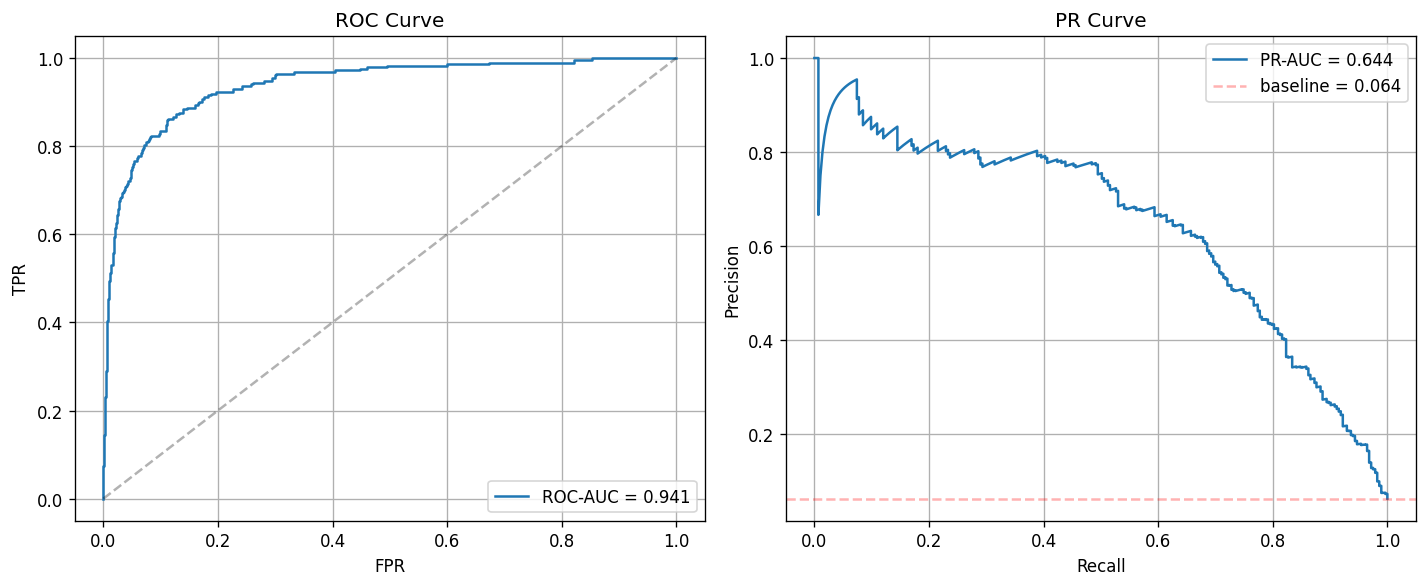

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y, probas_cv)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[0].legend()

prec, rec, thresholds = precision_recall_curve(y, probas_cv)
axes[1].plot(rec, prec, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].axhline(y.mean(), color="r", linestyle="--", alpha=0.3, label=f"baseline = {y.mean():.3f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="PR Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Calibration & multi-threshold evaluation

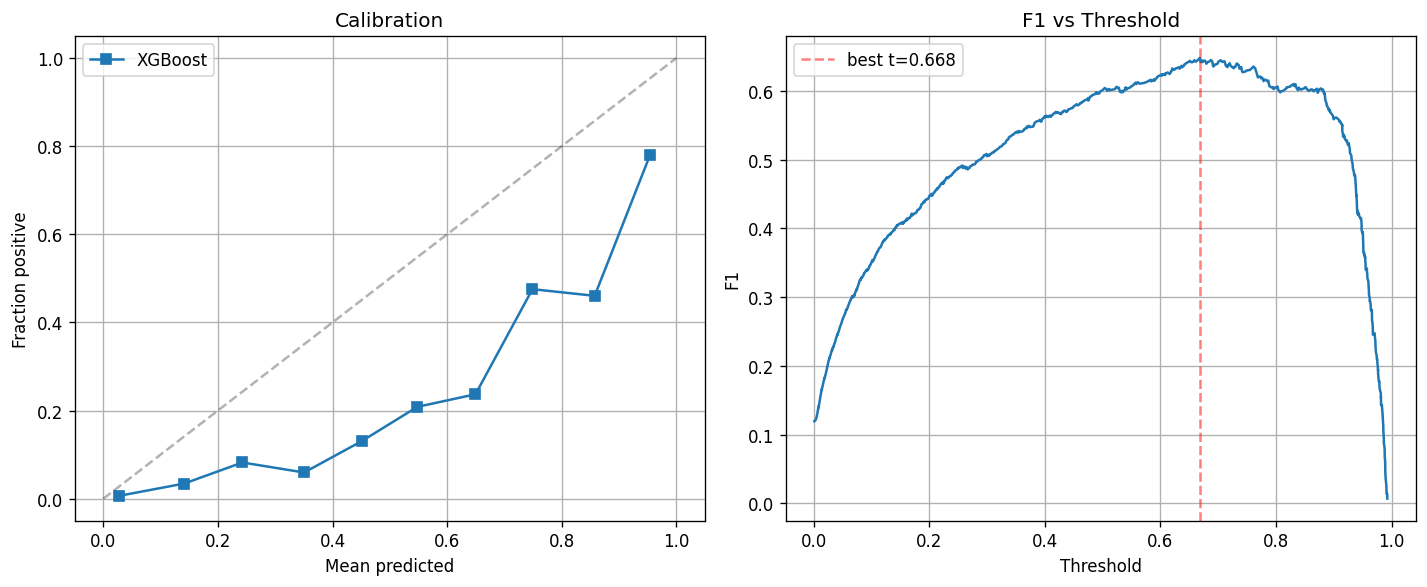

Best F1 threshold: 0.668  (F1 = 0.6476)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fraction_pos, mean_pred = calibration_curve(y, probas_cv, n_bins=10)
axes[0].plot(mean_pred, fraction_pos, "s-", label="XGBoost")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set(xlabel="Mean predicted", ylabel="Fraction positive", title="Calibration")
axes[0].legend()

f1_scores = []
for t in thresholds:
    preds = (probas_cv >= t).astype(int)
    f1_scores.append(f1_score(y, preds, zero_division=0))
best_idx = np.argmax(f1_scores)
best_t = thresholds[best_idx]
axes[1].plot(thresholds, f1_scores)
axes[1].axvline(best_t, color="r", linestyle="--", alpha=0.5, label=f"best t={best_t:.3f}")
axes[1].set(xlabel="Threshold", ylabel="F1", title="F1 vs Threshold")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Best F1 threshold: {best_t:.3f}  (F1 = {f1_scores[best_idx]:.4f})")

## 10. Confusion matrix

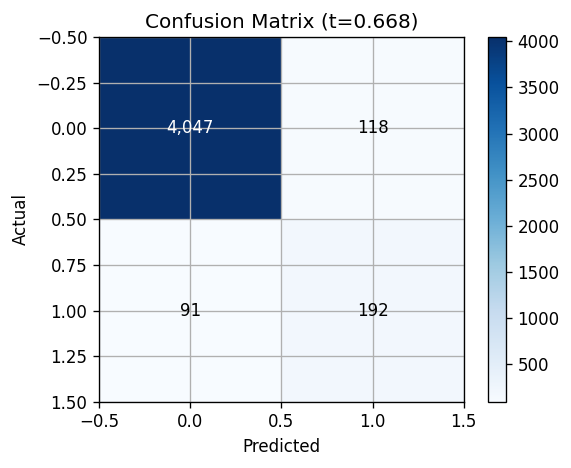

              precision    recall  f1-score   support

 no overtake       0.98      0.97      0.97      4165
    overtake       0.62      0.68      0.65       283

    accuracy                           0.95      4448
   macro avg       0.80      0.83      0.81      4448
weighted avg       0.96      0.95      0.95      4448



In [12]:
best_preds = (probas_cv >= best_t).astype(int)
cm = confusion_matrix(y, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set(xlabel="Predicted", ylabel="Actual", title=f"Confusion Matrix (t={best_t:.3f})")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(classification_report(y, best_preds, target_names=["no overtake", "overtake"]))

## 11. Battle-pair level evaluation

In [13]:
df_eval = df_train.copy()
df_eval["proba"] = probas_cv

pair_groups = df_eval.groupby(["race_name", "attacker", "defender"])
pair_max_proba = pair_groups["proba"].max()
pair_label = pair_groups["overtake"].max().astype(int)

pair_roc = roc_auc_score(pair_label, pair_max_proba)
pair_pr  = average_precision_score(pair_label, pair_max_proba)
print(f"Battle-pair evaluation (max proba per pair):")
print(f"  ROC-AUC : {pair_roc:.4f}")
print(f"  PR-AUC  : {pair_pr:.4f}")
print(f"  Pairs   : {len(pair_label):,}")
print(f"  Overtake rate: {pair_label.mean():.2%}")

Battle-pair evaluation (max proba per pair):
  ROC-AUC : 0.9213
  PR-AUC  : 0.7571
  Pairs   : 1,114
  Overtake rate: 21.81%


## 12. Temporal calibration per year

In [14]:
df_eval["year"] = df_train["year"].values

for yr in sorted(df_eval["year"].unique()):
    mask = df_eval["year"] == yr
    yi = df_eval.loc[mask, "overtake"].astype(int).values
    pi = df_eval.loc[mask, "proba"].values
    if len(np.unique(yi)) < 2:
        continue
    print(f"  {yr}  ROC-AUC={roc_auc_score(yi, pi):.4f}  "
          f"PR-AUC={average_precision_score(yi, pi):.4f}  "
          f"Brier={brier_score_loss(yi, pi):.4f}  n={mask.sum():,}")

  2022  ROC-AUC=0.9433  PR-AUC=0.6844  Brier=0.0601  n=676
  2023  ROC-AUC=0.9037  PR-AUC=0.4933  Brier=0.0572  n=1,653
  2024  ROC-AUC=0.9677  PR-AUC=0.7496  Brier=0.0398  n=2,119


## 13. Track-stratified evaluation

In [15]:
df_eval["track_type"] = df_train["track_type"].values

for tt in sorted(df_eval["track_type"].unique()):
    mask = df_eval["track_type"] == tt
    yi = df_eval.loc[mask, "overtake"].astype(int).values
    pi = df_eval.loc[mask, "proba"].values
    if len(np.unique(yi)) < 2:
        continue
    print(f"  {tt:15s}  ROC-AUC={roc_auc_score(yi, pi):.4f}  "
          f"PR-AUC={average_precision_score(yi, pi):.4f}  n={mask.sum():,}")

  low-speed        ROC-AUC=0.8711  PR-AUC=0.4166  n=642
  medium-speed     ROC-AUC=0.9393  PR-AUC=0.6531  n=3,806


## 14. Feature importance

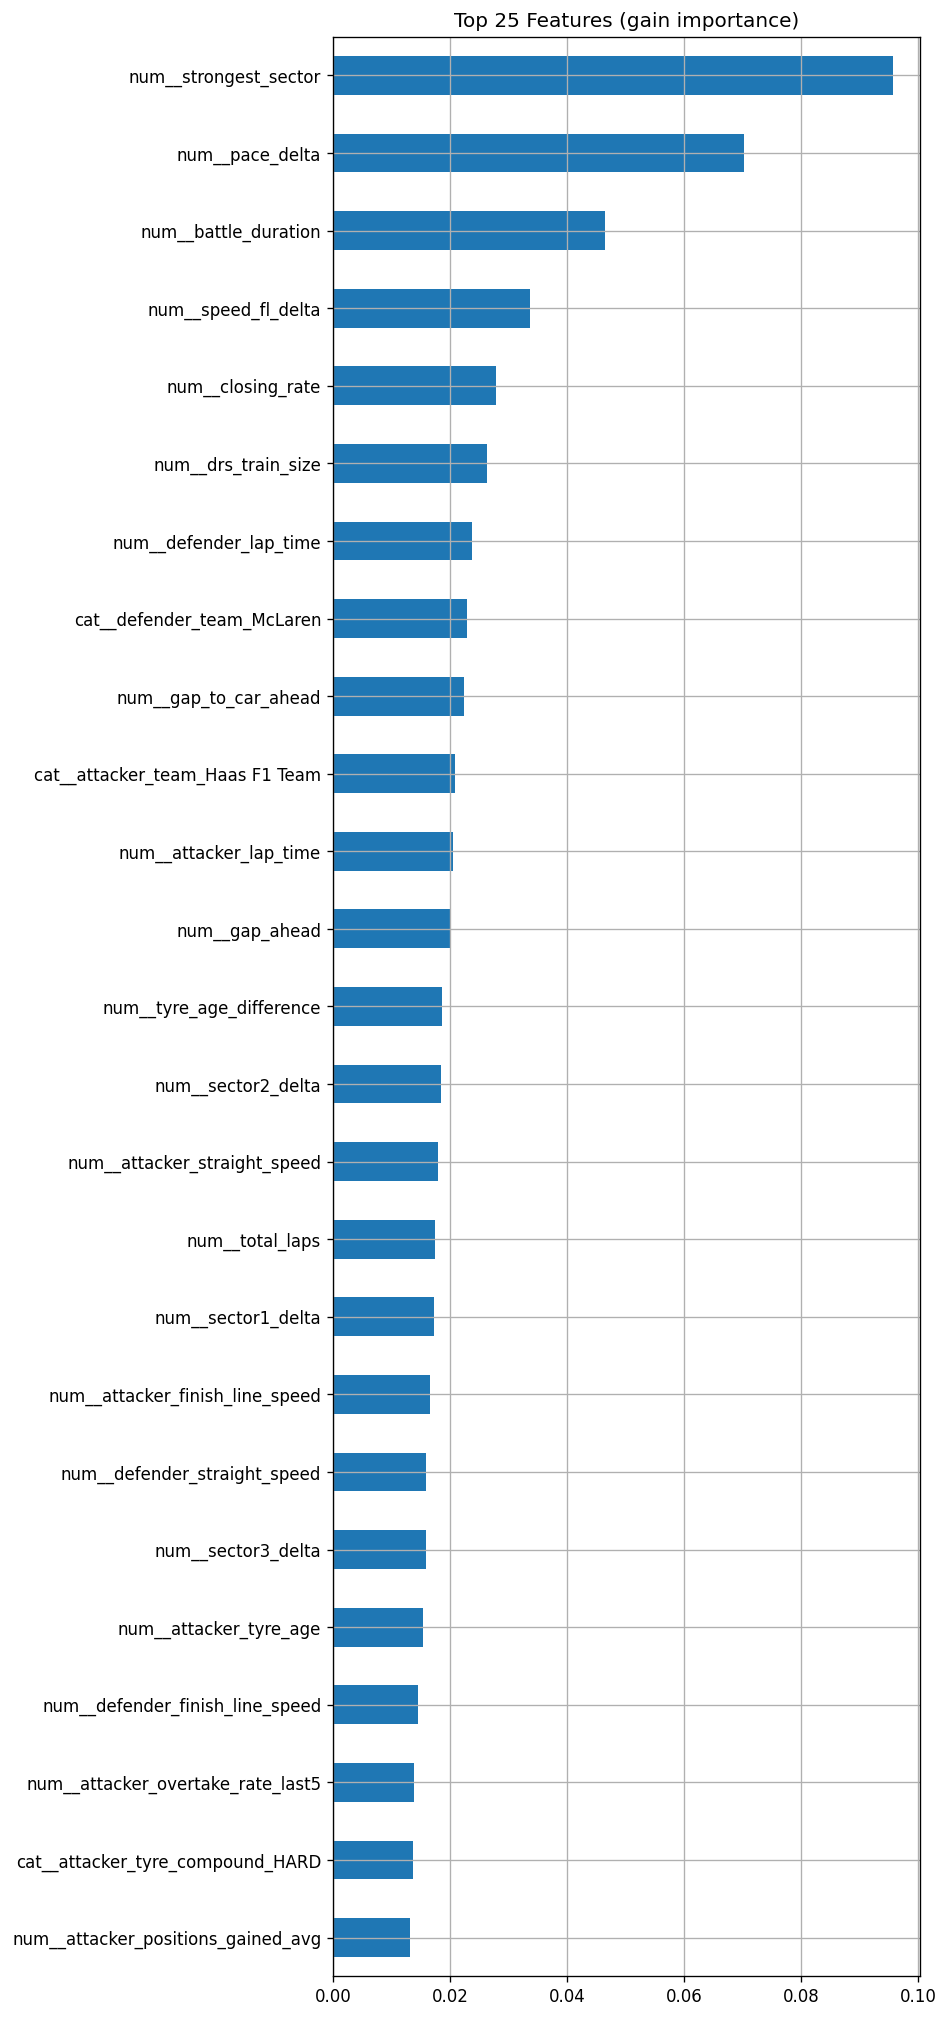

In [16]:
fi_clf = xgb.XGBClassifier(**best_params)
fi_clf.fit(X_transformed, y)

t_names_all = preprocessor.get_feature_names_out()
fi = pd.Series(fi_clf.feature_importances_, index=t_names_all).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(fi) * 0.18)))
fi.tail(25).plot.barh(ax=ax)
ax.set_title("Top 25 Features (gain importance)")
plt.tight_layout()
plt.show()

## 14a. SHAP visualizations

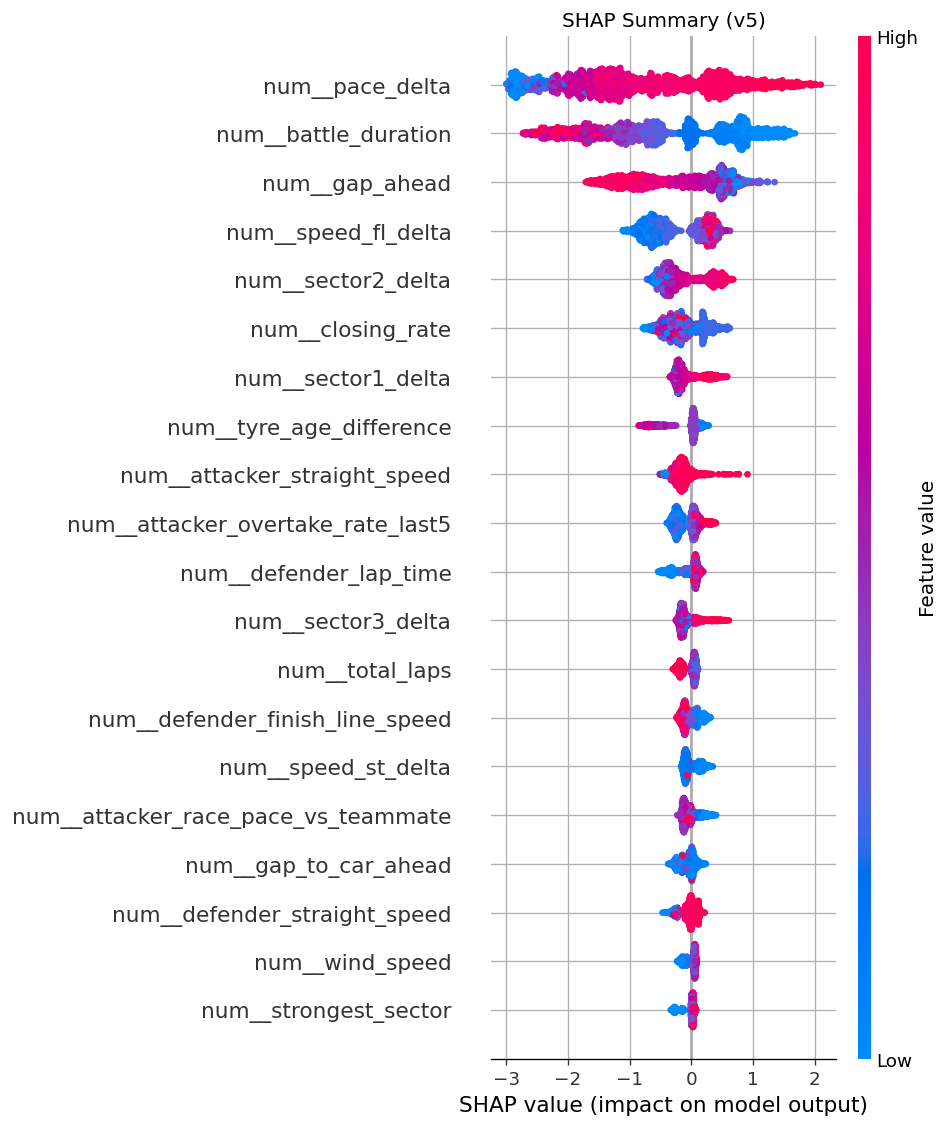

<Figure size 768x576 with 0 Axes>

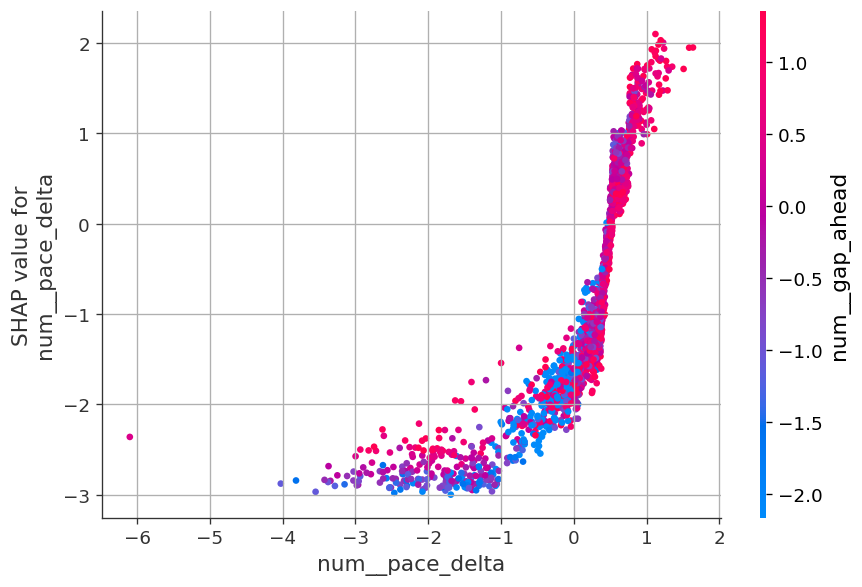

<Figure size 768x576 with 0 Axes>

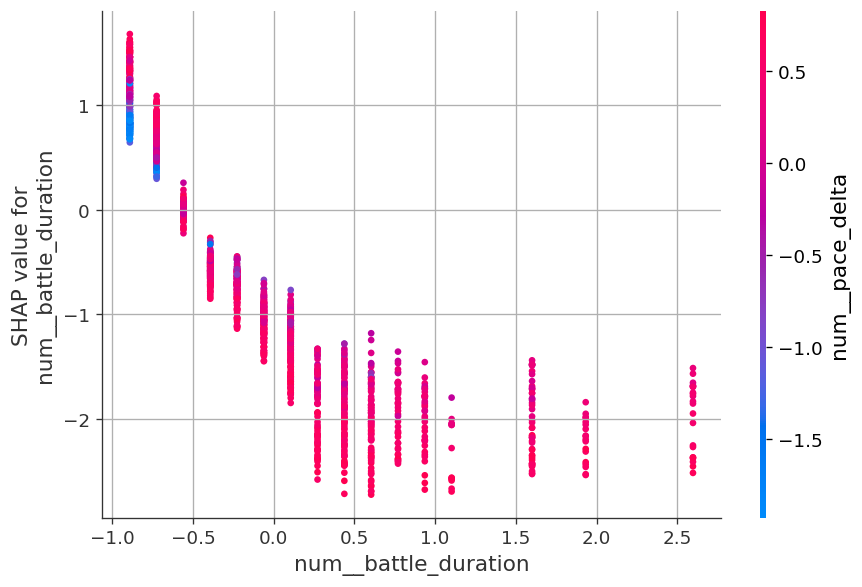

<Figure size 768x576 with 0 Axes>

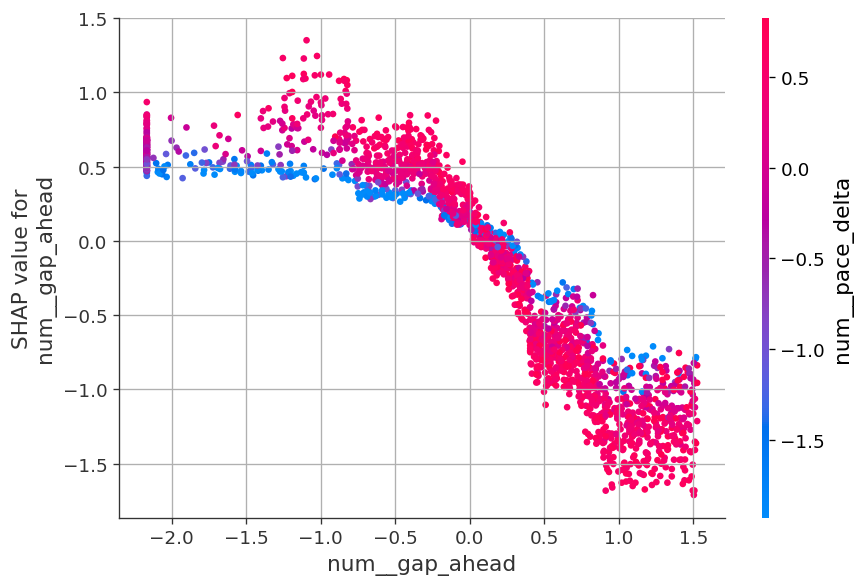

<Figure size 768x576 with 0 Axes>

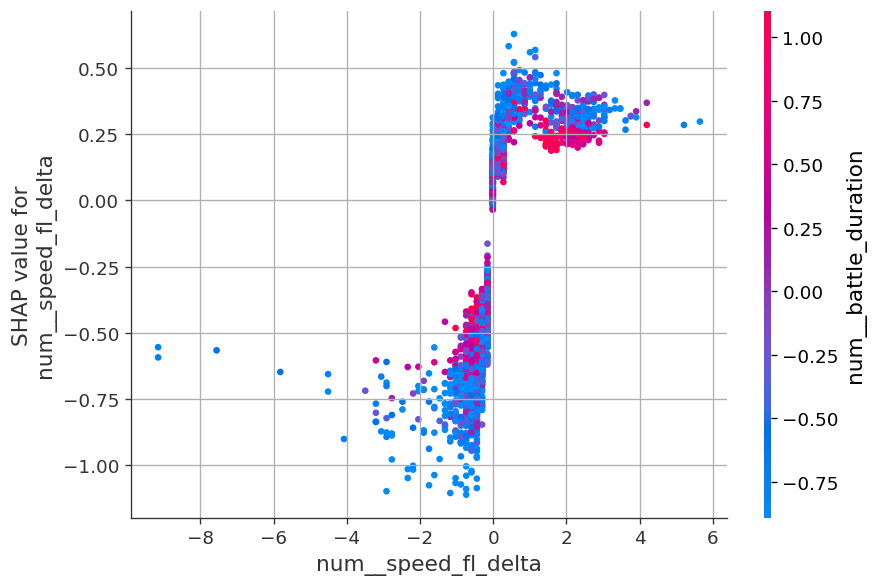

<Figure size 768x576 with 0 Axes>

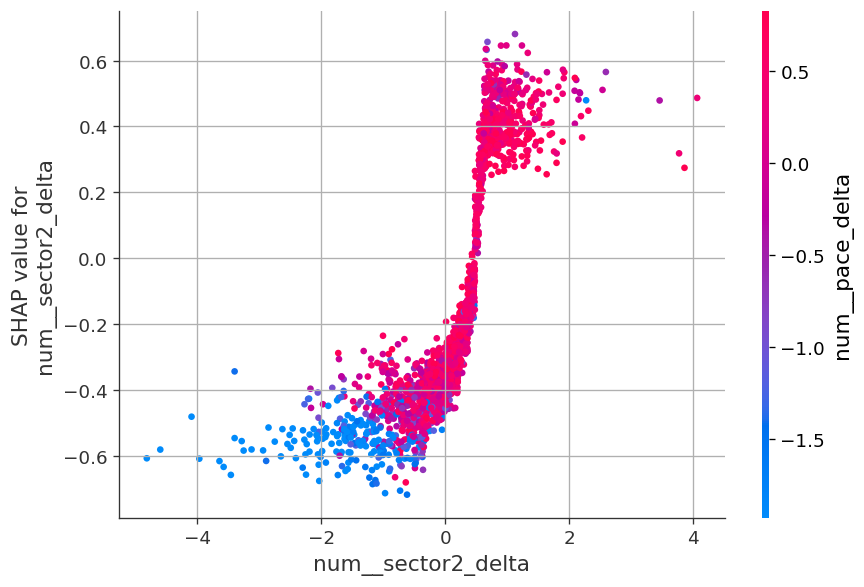

In [17]:
if shap is not None:
    probe_xgb_viz = xgb.XGBClassifier(**best_params)
    probe_xgb_viz.fit(X_transformed, y)
    n_viz = min(2000, X_transformed.shape[0])
    explainer_viz = shap.TreeExplainer(probe_xgb_viz)
    sv_viz = explainer_viz.shap_values(X_transformed[:n_viz])

    plt.figure()
    shap.summary_plot(sv_viz, X_transformed[:n_viz],
                      feature_names=list(t_names_all), show=False, max_display=20)
    plt.title("SHAP Summary (v5)")
    plt.tight_layout()
    plt.show()

    top5_idx = np.argsort(-np.mean(np.abs(sv_viz), axis=0))[:5]
    for idx in top5_idx:
        plt.figure()
        shap.dependence_plot(idx, sv_viz, X_transformed[:n_viz],
                             feature_names=list(t_names_all), show=False)
        plt.tight_layout()
        plt.show()
else:
    print("shap not installed — skipping SHAP plots")

## 14b. Battle-pair model (IP03 §1.1)

In [18]:
pair_train = aggregate_battle_pairs(df_train)
pair_test = aggregate_battle_pairs(df_test) if not df_test.empty else pd.DataFrame()

pair_feat = [c for c in pair_train.columns if c not in
             ["year", "race_name", "attacker", "defender", "overtake_pair", "overtake_within_3_pair", "round_number", "track", "track_type"]]
pair_X = pair_train[pair_feat].copy()
pair_y = pair_train["overtake_pair"].astype(int).values
pair_groups_arr = pair_train["race_name"].values

pair_cat = pair_X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
pair_num = pair_X.select_dtypes(include=["number"]).columns.tolist()

pair_pre = ColumnTransformer([
    ("num", StandardScaler(), pair_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), pair_cat),
])
pair_Xt = pair_pre.fit_transform(pair_X)

spw = (pair_y == 0).sum() / max((pair_y == 1).sum(), 1)
pair_xgb = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              scale_pos_weight=spw, eval_metric="aucpr",
                              random_state=42, n_jobs=-1)
pair_gkf = GroupKFold(n_splits=min(5, len(np.unique(pair_groups_arr))))
pair_probas = cross_val_predict(pair_xgb, pair_Xt, pair_y, cv=pair_gkf,
                                groups=pair_groups_arr, method="predict_proba", n_jobs=1)[:, 1]

pair_roc2 = roc_auc_score(pair_y, pair_probas)
pair_pr2  = average_precision_score(pair_y, pair_probas)
pair_brier2 = brier_score_loss(pair_y, pair_probas)
print(f"Battle-pair model CV:")
print(f"  ROC-AUC : {pair_roc2:.4f}")
print(f"  PR-AUC  : {pair_pr2:.4f}")
print(f"  Brier   : {pair_brier2:.4f}")

if not pair_test.empty:
    pXt = pair_pre.transform(pair_test[pair_feat])
    pair_xgb.fit(pair_Xt, pair_y)
    p2025 = pair_xgb.predict_proba(pXt)[:, 1]
    py2025 = pair_test["overtake_pair"].astype(int).values
    print(f"\nBattle-pair holdout (2025):")
    print(f"  ROC-AUC : {roc_auc_score(py2025, p2025):.4f}")
    print(f"  PR-AUC  : {average_precision_score(py2025, p2025):.4f}")

Battle-pair model CV:
  ROC-AUC : 0.9163
  PR-AUC  : 0.7390
  Brier   : 0.0927



Battle-pair holdout (2025):
  ROC-AUC : 0.9001
  PR-AUC  : 0.6984


## 14c. Temporal-progressive evaluation

In [19]:
def eval_window(train_years, test_years):
    dtr = df_train_raw[~df_train_raw['pit_stop_involved']].copy()
    dte = df_test_raw[~df_test_raw['pit_stop_involved']].copy() if not df_test_raw.empty else pd.DataFrame()
    combined = pd.concat([dtr, dte], ignore_index=True) if not dte.empty else dtr.copy()
    combined = engineer_features(combined)

    tr = combined[combined['year'].isin(train_years)]
    te = combined[combined['year'].isin(test_years)]
    if te.empty or tr.empty:
        return None

    fc = [c for c in FEATURE_COLS if c in tr.columns]
    Xtr = tr[fc]; ytr = tr[TARGET].astype(int).values
    Xte = te[fc]; yte = te[TARGET].astype(int).values

    cat_c = Xtr.select_dtypes(include=['object','category','bool']).columns.tolist()
    num_c = Xtr.select_dtypes(include=['number']).columns.tolist()
    pre = ColumnTransformer([
        ('num', StandardScaler(), num_c),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_c),
    ])
    Xtr_t = pre.fit_transform(Xtr)
    Xte_t = pre.transform(Xte)

    clf = xgb.XGBClassifier(**best_params)
    clf.fit(Xtr_t, ytr)
    pte = clf.predict_proba(Xte_t)[:, 1]
    return {
        'train': train_years, 'test': test_years,
        'roc_auc': roc_auc_score(yte, pte),
        'pr_auc': average_precision_score(yte, pte),
        'brier': brier_score_loss(yte, pte),
        'n_test': len(yte),
    }

temporal_results = []
for tr, te in [([2022], [2023]), ([2022, 2023], [2024]), ([2022, 2023, 2024], [2025])]:
    r = eval_window(tr, te)
    if r:
        temporal_results.append(r)
        print(f"  Train {r['train']} → Test {r['test']}: "
              f"ROC-AUC={r['roc_auc']:.4f}  PR-AUC={r['pr_auc']:.4f}  "
              f"Brier={r['brier']:.4f}  n={r['n_test']}")

  Train [2022] → Test [2023]: ROC-AUC=0.8883  PR-AUC=0.4734  Brier=0.0720  n=1653


  Train [2022, 2023] → Test [2024]: ROC-AUC=0.9726  PR-AUC=0.7945  Brier=0.0345  n=2119


  Train [2022, 2023, 2024] → Test [2025]: ROC-AUC=0.9573  PR-AUC=0.6910  Brier=0.0414  n=1564


## 14d. Leave-one-circuit-out (LOCO) evaluation

In [20]:
vc = df_train['track'].value_counts()
hold_track = vc.index[0]

loco_train = df_train[df_train['track'] != hold_track]
loco_test  = df_train[df_train['track'] == hold_track]

fc = [c for c in FEATURE_COLS if c in loco_train.columns]
cat_c = loco_train[fc].select_dtypes(include=['object','category','bool']).columns.tolist()
num_c = loco_train[fc].select_dtypes(include=['number']).columns.tolist()

pre_loco = ColumnTransformer([
    ('num', StandardScaler(), num_c),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_c),
])
Xtr_loco = pre_loco.fit_transform(loco_train[fc])
ytr_loco = loco_train[TARGET].astype(int).values
Xte_loco = pre_loco.transform(loco_test[fc])
yte_loco = loco_test[TARGET].astype(int).values

clf_loco = xgb.XGBClassifier(**best_params)
clf_loco.fit(Xtr_loco, ytr_loco)
pte_loco = clf_loco.predict_proba(Xte_loco)[:, 1]

print(f"LOCO — held out: {hold_track} ({len(yte_loco):,} battles)")
print(f"  ROC-AUC: {roc_auc_score(yte_loco, pte_loco):.4f}")
print(f"  PR-AUC : {average_precision_score(yte_loco, pte_loco):.4f}")
print(f"  Brier  : {brier_score_loss(yte_loco, pte_loco):.4f}")

LOCO — held out: MONACO (642 battles)
  ROC-AUC: 0.8692
  PR-AUC : 0.4311
  Brier  : 0.0210


## 14e. Multi-horizon target analysis (overtake_within_3)

In [21]:
if 'overtake_within_3' in df_train.columns:
    y_w3 = df_train['overtake_within_3'].astype(int).values

    clf_w3 = xgb.XGBClassifier(**{**best_params, 'scale_pos_weight': (y_w3 == 0).sum() / max((y_w3 == 1).sum(), 1)})
    p_w3 = cross_val_predict(clf_w3, X_transformed, y_w3, cv=gkf,
                             groups=groups, method='predict_proba', n_jobs=1)[:, 1]

    print(f"Multi-horizon target: overtake_within_3")
    print(f"  ROC-AUC : {roc_auc_score(y_w3, p_w3):.4f}")
    print(f"  PR-AUC  : {average_precision_score(y_w3, p_w3):.4f}")
    print(f"  Brier   : {brier_score_loss(y_w3, p_w3):.4f}")
    print(f"  Positive rate: {y_w3.mean():.2%}")

    if X_test is not None and 'overtake_within_3' in df_test.columns:
        clf_w3.fit(X_transformed, y_w3)
        p_w3_test = clf_w3.predict_proba(preprocessor.transform(X_test))[:, 1]
        yw3_test = df_test['overtake_within_3'].astype(int).values
        print(f"\n  2025 holdout:")
        print(f"    ROC-AUC : {roc_auc_score(yw3_test, p_w3_test):.4f}")
        print(f"    PR-AUC  : {average_precision_score(yw3_test, p_w3_test):.4f}")
else:
    print("overtake_within_3 not available in data")

Multi-horizon target: overtake_within_3
  ROC-AUC : 0.8457
  PR-AUC  : 0.5884
  Brier   : 0.1174
  Positive rate: 14.37%



  2025 holdout:
    ROC-AUC : 0.8674
    PR-AUC  : 0.6370


## 15. Save model artefacts

In [22]:
import joblib
import json as _json
import datetime

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

final_xgb = xgb.XGBClassifier(**best_params)
final_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_all = final_preprocessor.fit_transform(X)
final_cal = CalibratedClassifierCV(final_xgb, method="isotonic", cv=5)
final_cal.fit(X_all, y)

full_pipeline = Pipeline([
    ("preprocess", final_preprocessor),
    ("classifier", final_cal),
])

model_path = ARTIFACTS_DIR / "overtake_model_v5.pkl"
meta_path  = ARTIFACTS_DIR / "overtake_model_v5_meta.json"

joblib.dump(full_pipeline, model_path)

meta = {
    "model": "XGBoost",
    "calibration": "isotonic",
    "features": FEATURE_COLS,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "best_params": {k: v for k, v in best_params.items() if k != "n_jobs"},
    "threshold": float(best_t),
    "train_years": TRAIN_YEARS,
    "train_rows": int(len(X)),
    "overtake_rate": float(y.mean()),
    "cv_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "brier": float(brier),
    },
    "data_version": "v5",
    "ip04_improvements": [
        "team_constructor_features",
        "team_pace_ranking",
        "same_team_battle_flag",
        "gap_to_surrounding_cars",
        "drs_train_detection",
        "race_phase_buckets",
        "stint_phase_buckets",
        "positions_gained_rolling",
        "quali_vs_teammate",
        "race_pace_vs_teammate",
        "regularization_tuning",
    ],
    "baseline_model": "v4 IP03 (model_testing_4, data v4)",
    "saved_at": datetime.datetime.now().isoformat(),
}
meta_path.write_text(_json.dumps(meta, indent=2))

print(f"Model saved    -> {model_path}")
print(f"Metadata saved -> {meta_path}")
print(f"Trained on     : {TRAIN_YEARS}  ({len(X):,} battles)")
print(f"Decision threshold: {best_t:.3f}")

Model saved    -> artifacts/overtake_model_v5.pkl
Metadata saved -> artifacts/overtake_model_v5_meta.json
Trained on     : [2022, 2023, 2024]  (4,448 battles)
Decision threshold: 0.668


## 15b. Venn-Abers calibration

In [23]:
try:
    from venn_abers import VennAbersCalibrator

    va_base = xgb.XGBClassifier(**best_params)
    va = VennAbersCalibrator(va_base)
    va.fit(X_transformed, y)
    va_proba = va.predict_proba(X_transformed)
    va_point = va_proba[:, 1]
    va_brier = brier_score_loss(y, va_point)
    print(f"Venn-Abers calibration Brier: {va_brier:.4f} (isotonic: {brier:.4f})")
except Exception as e:
    print(f"Venn-Abers skipped: {e}")

Venn-Abers skipped: For Inductive Venn-ABERS please provide either calibration or proper train set size


## 16. Holdout evaluation on 2025 data

In [24]:
if X_test is not None and y_test is not None:
    probas_2025 = full_pipeline.predict_proba(X_test)[:, 1]
    roc_2025 = roc_auc_score(y_test, probas_2025)
    pr_2025  = average_precision_score(y_test, probas_2025)
    brier_2025 = brier_score_loss(y_test, probas_2025)

    print(f"2025 Holdout Results:")
    print(f"  ROC-AUC : {roc_2025:.4f}")
    print(f"  PR-AUC  : {pr_2025:.4f}")
    print(f"  Brier   : {brier_2025:.4f}")
    print(f"  n       : {len(y_test):,}")

    preds_2025 = (probas_2025 >= best_t).astype(int)
    print(f"\n{classification_report(y_test, preds_2025, target_names=['no overtake', 'overtake'])}")
else:
    roc_2025 = pr_2025 = brier_2025 = None
    print("No 2025 holdout data")

2025 Holdout Results:
  ROC-AUC : 0.9603
  PR-AUC  : 0.6858
  Brier   : 0.0274
  n       : 1,564

              precision    recall  f1-score   support

 no overtake       0.97      1.00      0.98      1482
    overtake       0.87      0.40      0.55        82

    accuracy                           0.97      1564
   macro avg       0.92      0.70      0.77      1564
weighted avg       0.96      0.97      0.96      1564



## 17. Comparison: v4 (IP03) vs v5 (IP04)

In [25]:
import json

v4_meta_path = Path("artifacts/overtake_model_v4_meta.json")
if v4_meta_path.exists():
    v4_meta = json.loads(v4_meta_path.read_text())
    v4_cv = v4_meta.get("cv_metrics", {})
else:
    v4_cv = {"roc_auc": 0.869, "pr_auc": 0.394, "brier": 0.098}

v4_2025 = {"roc_auc": 0.894, "pr_auc": 0.469, "brier": 0.036}

print("=" * 65)
print(f"{'Metric':<20} {'v4 (IP03)':>12} {'v5 (IP04)':>12} {'Delta':>10}")
print("-" * 65)
for label, v4v, v5v in [
    ("ROC-AUC (CV)",    v4_cv.get('roc_auc', 0), roc_auc),
    ("PR-AUC (CV)",     v4_cv.get('pr_auc', 0),  pr_auc),
    ("Brier (CV)",      v4_cv.get('brier', 0),    brier),
]:
    delta = v5v - v4v
    sign = "+" if delta >= 0 else ""
    print(f"  {label:<18} {v4v:>12.4f} {v5v:>12.4f} {sign}{delta:>9.4f}")

if roc_2025 is not None:
    print("-" * 65)
    for label, v4v, v5v in [
        ("ROC-AUC (2025)",  v4_2025['roc_auc'], roc_2025),
        ("PR-AUC (2025)",   v4_2025['pr_auc'],  pr_2025),
        ("Brier (2025)",    v4_2025['brier'],    brier_2025),
    ]:
        delta = v5v - v4v
        sign = "+" if delta >= 0 else ""
        print(f"  {label:<18} {v4v:>12.4f} {v5v:>12.4f} {sign}{delta:>9.4f}")

print("=" * 65)

Metric                  v4 (IP03)    v5 (IP04)      Delta
-----------------------------------------------------------------
  ROC-AUC (CV)             0.8694       0.9405 +   0.0711
  PR-AUC (CV)              0.3944       0.6442 +   0.2498
  Brier (CV)               0.0983       0.0493   -0.0489
-----------------------------------------------------------------
  ROC-AUC (2025)           0.8940       0.9603 +   0.0663
  PR-AUC (2025)            0.4690       0.6858 +   0.2168
  Brier (2025)             0.0360       0.0274   -0.0086
